#### Com a análise explorativa feita no arquivo [analise_exploratoria.py](analise_exploratoria.ipynb), surgem algumas perguntas, junto ao proposto no arquivo [descricao_desafio.md](../descricao_desafio.md) feito por josé Gonçalves Jr.

1. Qual o comparativo da taxa de execução no período dos anos nas funções de Saúde, Educação e Cultura?
2. Quais capitais pagam uma proporção maior do que empenha nessas 3 funções? em resumo, quais capitais conseguem além de pagar tudo empenhado, pagar as despessas processadas dos anos anteriores? E quais deixam mais despesas liquidadas ou não, para o próximo ano?
3. Maceió investe mais em Cultura do que a média geral das outras capitais brasileiras? (per-capta)
4. Qual a evolução da taxa de execução dessas áreas? Se estiver crescendo a área da cultura, qual subárea está tendo maior priorização?

Essas perguntas são norteadores e dão contexto ao que se espera que essa análise irá percorrer.


In [2]:
""" Importação das dependências para a análise """
from src.query_descritiva import tabela_filtrada, tabela_com_taxa_execucao
from src.visualizacao.linha_comparativo_tava_execucao import plotar_linha_taxa_execucao
from src.config.grafico import configurar_graficos
from src.config.ConexaoBanco import db

configurar_graficos()

#### Tabela base para as análises

In [4]:
tabela_filtrada(db.con).df().describe(include="all")

,instituicao,uf,ano_exercicio,nome_funcao,nome_subfuncao,populacao,valor_empenhado,valor_liquidado,valor_pago,valor_restos_a_pagar_nao_processados,valor_restos_a_pagar_processados
count,2023,2023,2023.000000,2023,1633,2.023000e+03,2.022000e+03,2.017000e+03,2.016000e+03,1.595000e+03,1.622000e+03
unique,26,26,NaN,3,17,NaN,NaN,NaN,NaN,NaN,NaN
top,Prefeitura Municipal de São Paulo - SP,SP,NaN,Saúde,Administração Geral,NaN,NaN,NaN,NaN,NaN,NaN
freq,99,99,NaN,875,295,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2022.010875,NaN,NaN,1.950859e+06,6.039807e+08,5.642435e+08,5.503612e+08,5.131924e+07,1.761845e+07
std,NaN,NaN,1.415220,NaN,NaN,2.666173e+06,1.892568e+09,1.741578e+09,1.712665e+09,2.377022e+08,6.423491e+07
min,NaN,NaN,2020.000000,NaN,NaN,2.991270e+05,2.210100e+02,2.210100e+02,2.210100e+02,-2.471369e+07,-2.014236e+07
25%,NaN,NaN,2021.000000,NaN,NaN,6.053090e+05,1.277061e+07,1.126719e+07,1.089606e+07,8.766004e+05,2.052075e+05
50%,NaN,NaN,2022.000000,NaN,NaN,1.031597e+06,7.494385e+07,7.184843e+07,6.825971e+07,4.785806e+06,1.601472e+06
75%,NaN,NaN,2023.000000,NaN,NaN,2.054731e+06,4.756798e+08,4.382910e+08,4.270184e+08,2.354593e+07,8.997252e+06


### 1. Qual o comparativo da taxa de execução no período dos anos nas funções de Saúde, Educação e Cultura?

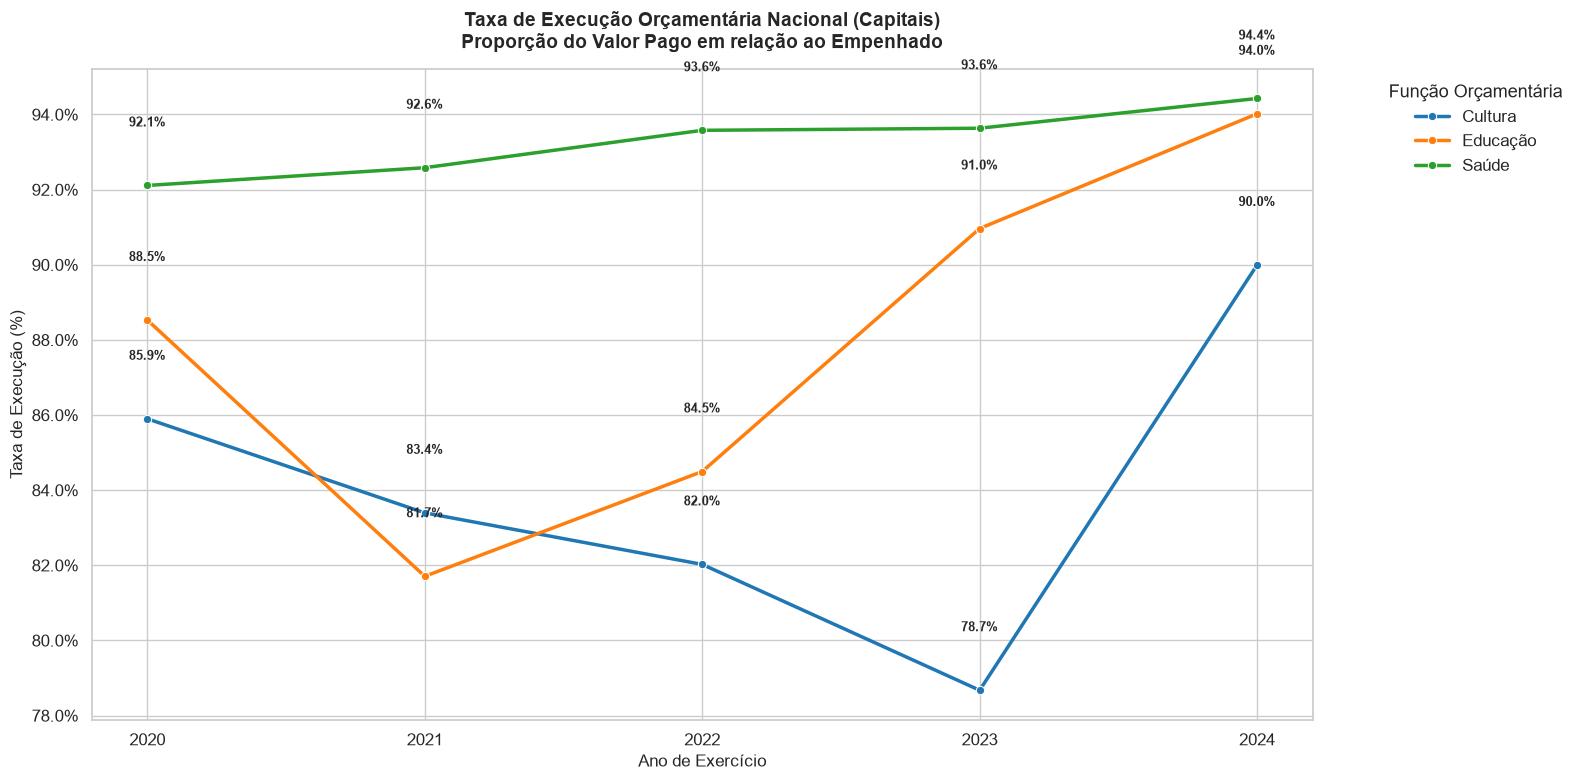

In [3]:
df = tabela_com_taxa_execucao(db.con).df()
plotar_linha_taxa_execucao(df)

##### O gráfico revela o comportamento da taxa de execução orçamentária para as três funções analisadas entre 2020 e 2024:

`Saúde`: Apresenta um crescimento contínuo ao longo dos anos, com exceção do período entre 2022 e 2023, no qual a taxa de execução se estabilizou exatamente em 93.6%.

`Educação`: Registra uma queda abrupta de 2020 para 2021 (redução de 88.5% para 81.7%), dinâmica que coincide com o período da pandemia de COVID-19, seguida por uma recuperação constante nos anos posteriores.

`Cultura`: Mostra uma tendência de declínio até 2023, atingindo o ponto mais baixo da série com 78.7%. No entanto, a função apresenta uma forte reversão em 2024, registrando um aumento de mais de 11 pontos percentuais em apenas um ano e alcançando 90.0% de execução.